##### AI TECH - Akademia Innowacyjnych Zastosowań Technologii Cyfrowych. Programu Operacyjnego Polska Cyfrowa na lata 2014-2020
<hr>

<br>
<br>
<br>
<br>
<br>
<br>
<br>
<center>
    <h1 style = "font-size:48px; font-weight:normal"><b>AI</b>-TECH</h1>
    <br>
<br>
<br>
<br>
    <h1 style = "font-size:24px; font-weight:normal">Przykład 4 DO LABORATORIUM 1</h1>
    <h1 style = "font-size:24px">z UCZENIA MASZYNOWEGO</h1>
    <h1 style = "font-size:24px">Regresja liniowa i logistyczna</h1>
    <h1 style = "font-size:24px">Tomasz Neumann</h1>
    <h3 style = "font-size:21px">Regresja logistyczna w scikit-learn</h3>
</center>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
    </body>
    </html>

![stopka.svg](stopka.svg)

<center>
Projekt współfinansowany ze środków Unii Europejskiej w ramach Europejskiego Funduszu Rozwoju Regionalnego 
Program Operacyjny Polska Cyfrowa na lata 2014-2020,
Oś Priorytetowa nr 3 "Cyfrowe kompetencje społeczeństwa" Działanie  nr 3.2 "Innowacyjne rozwiązania na rzecz aktywizacji cyfrowej" 
Tytuł projektu:  „Akademia Innowacyjnych Zastosowań Technologii Cyfrowych (AI Tech)”
    </center>

<hr>

# 1. Przykład 4

Regresja logistyczna służy do szacowania prawdopodobieństwa przynależności przykładu do danej klasy. W przypadku oszacowania prawdopodobieństwa wiekszego od $50\%$, model może prognozować, że przykład należy do tej klasy (tzw. klasy pozytywnej) - w przeciwnym razie zostaje przypisany do tzw. klasy negatywnej. Jak nie trudno zauważyć, model taki wykazuje cechy klasyfikatora binarnego.
W przypadku regresji logistycznej także należy wyliczyć ważoną sumę cech wejściowych, jednak rezultatem jest funkcja logistyczna, a nie bezpośrednio wyniki.
Postać wektorową modelu logistycznego można zapisać jako
$$\hat{p} = h_{\theta}(\mathbf{x}) = \sigma(\mathbf{x}^T\boldsymbol\theta)$$
przy czym funkcja logistyczna w postaci $\sigma(\cdot)$ jest funkcją sigmoidalną
$$\sigma(t)  = \dfrac{1}{1+e^{-t}},$$
której wartości są z przedziału od 0 do 1. Poniżej został przedstawiany wykres funkcji logistycznej.
Na początku, tak jak zwykle zaimportujemy podstawowe biblioteki do naszego projektu

In [1]:
# Import podstawowych bibliotek języka Python
import numpy as np  # operacje numeryczne
import matplotlib  # wykresy i ich ustawienia
import matplotlib.pyplot as plt  # tworzenie wykresu

oraz stworzony zostanie zbiór pięciuset danych <i>t</i> z przedziału od -10 do 10. Po dokonaniu odpowiednich ustawień wykresu oraz wykreśleniu wygenerowanych danych wraz z liniami pomocniczymi, wyświetli się wykres funcji sigmoidalnej, której wartości są bardzo bliskie zera lub jedności w zakresie swojej dziedziny, co sprawia, że nadaje się do stosowania w metodach klasyfikacyjnych.

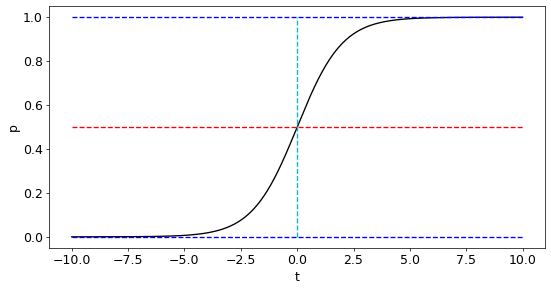

In [2]:
dataset_training_size = 500
t = x_t = np.linspace(-10, 10, dataset_training_size).astype(np.float32)
sigma = (1+np.exp(-t))**(-1)

# Wizualizacja wygenerowanych danych
# Ustawienia związane z wyświetlaniem
matplotlib.rcParams.update({'font.size': 14})
f = plt.figure(figsize=(10, 5), dpi=64)
f1 = f.add_subplot(111)
f1.set_xlabel('t')
f1.set_ylabel('p')
f1.plot(t,sigma, "k")
#wykreślenie linii pomocniczych
f1.plot(t,0*t+1, "b--")
f1.plot(t,0*t, "b--")
f1.plot(t,0*t+0.5, "r--")
f1.plot(0*t,sigma, "c--")
plt.show()

Na podstawie powyższego wykresu, można łatwo obliczyć prognozę, gdyż model regresji logistycznej przewiduję 1, jeżeli wynik $\mathbf{x}^T\boldsymbol\theta$ jest dodatni ($t\geq 0$) natomiast 0, jeżeli jest ujemny ($t < 0$).
Poniżej został przedstawiony kod, umożliwiający dokonać klasyfikacji binarnej z jedną zmienną (zbiór cyfr) do dwóch klas.

Dodatkowo do projektu zaimportujemy pakiet scikit-learn, w którym jest już zaimplementowany algorytm regresji logistycznej oraz wiele innych użytecznych narzędzi, które będziemy wykorzystywać w trakcie tego przykładu.

In [5]:
# Import dodatkowej biblietki scikit-learn
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix


Na potrzeby tego przykładu stworzymy tablice NumPy równomiernie rozłożonych wartości wejściowych $x$ i wyjściowych $y$. Tablica $x$ musi być dwuwymiarowa, w której powinna być jedna kolumna dla każdego wejścia, a liczba wierszy powinna być równa liczbie obserwacji. Tablica $y$ jest jednowymiarową tablicą z 10-cioma elementami.

In [6]:
# Stworzenie przykładowych danych

# Dwuwymiarowa tablica danych wejściowych:
# jedna kolumna dla jednego wejścia, liczba wierszy równa liczbie obserwacji
x = np.arange(10).reshape(-1, 1)
y = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
#wyświetlenie kontrolne utworzonych danych
print(x)
print(y)


[[0]
 [1]
 [2]
 [3]
 [4]
 [5]
 [6]
 [7]
 [8]
 [9]]
[0 0 0 0 1 1 1 1 1 1]


Zbudowanie modelu klasyfikacji nastąpi za pomocą klasy LogisticRegression. Klasa ta ma kilka opcjonalnych parametrów, które definiują zachowanie modelu - więcej informacji znajdziesz na stronie https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html.
Trening modelu następuje po wywołaniu metody <i>fit</i> na tak spreparowanych wcześniej danych.

In [7]:
# Zbudowanie modelu klasyfikacji za pomocą klasy LogisticRegression
# https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html
model = LogisticRegression(solver='liblinear', random_state=0)
# wytrenowanie modelu na podstawie wcześniej wygenerowanych danych
model.fit(x, y)

LogisticRegression(random_state=0, solver='liblinear')

Informacje z dokumentacji na temat <b>sklearn.linear_model.LogisticRegression</b>

<dt id="sklearn.linear_model.LogisticRegression">
<em class="property">class </em><code class="sig-prename descclassname">sklearn.linear_model.</code><code class="sig-name descname">LogisticRegression</code><span class="sig-paren">(</span><em class="sig-param"><span class="n">penalty</span><span class="o">=</span><span class="default_value">'l2'</span></em>, <em class="sig-param"><span class="o">*</span></em>, <em class="sig-param"><span class="n">dual</span><span class="o">=</span><span class="default_value">False</span></em>, <em class="sig-param"><span class="n">tol</span><span class="o">=</span><span class="default_value">0.0001</span></em>, <em class="sig-param"><span class="n">C</span><span class="o">=</span><span class="default_value">1.0</span></em>, <em class="sig-param"><span class="n">fit_intercept</span><span class="o">=</span><span class="default_value">True</span></em>, <em class="sig-param"><span class="n">intercept_scaling</span><span class="o">=</span><span class="default_value">1</span></em>, <em class="sig-param"><span class="n">class_weight</span><span class="o">=</span><span class="default_value">None</span></em>, <em class="sig-param"><span class="n">random_state</span><span class="o">=</span><span class="default_value">None</span></em>, <em class="sig-param"><span class="n">solver</span><span class="o">=</span><span class="default_value">'lbfgs'</span></em>, <em class="sig-param"><span class="n">max_iter</span><span class="o">=</span><span class="default_value">100</span></em>, <em class="sig-param"><span class="n">multi_class</span><span class="o">=</span><span class="default_value">'auto'</span></em>, <em class="sig-param"><span class="n">verbose</span><span class="o">=</span><span class="default_value">0</span></em>, <em class="sig-param"><span class="n">warm_start</span><span class="o">=</span><span class="default_value">False</span></em>, <em class="sig-param"><span class="n">n_jobs</span><span class="o">=</span><span class="default_value">None</span></em>, <em class="sig-param"><span class="n">l1_ratio</span><span class="o">=</span><span class="default_value">None</span></em><span class="sig-paren">)</span></dt>
Należy zauważyć, że wykorzystane wyżej wywołanie inicjujące model regresji logistycznej poprzez wybór metody mającej doprowadzić do dopasowania modelu do danych wiąże się także z ustawieniami wielu innych pararametrów wywołania, które są ustawione standardowo domyślnymi wartościami.
Przy tak zdefiniownym modelu można także sprawdzać właściwości stworzonego modelu. Atrybut <i>.classes_</i> wywałany na stworzonym modelu wyświetli tablicę indywidualnych wartości znajdujących się w $y$. Można także pobrać wartości dla modelu liniowego za pomocą <i>.intercept_</i> oraz <i>model.coef_</i>.

In [8]:
# Wyświetlenie informacji o modelu

# wyświetlenie wartości klas y
print('Klasy występujące w  modelu: ', model.classes_)
# parametry prostej, opisujące nachylenie krzywej podziału na klasy
print('a0: ', model.intercept_)
print('a1: ', model.coef_)

Klasy występujące w  modelu:  [0 1]
a0:  [-1.04608067]
a1:  [[0.51491375]]


Dla tak zdefiniowanego modelu za pomocą <i>.predict_proba()</i> można zwrócić macierz 'prawdopodobieństwa', w której pierwsza kolumna w tym przypadku informuje o szansie przynależności do klasy 0, a druga kolumna informuje o szansie przynależności do klasy 1 pojedynczej obserwacji. Sprawdzenie predykcji próbek wejściowych do określonych klas można uzyskać korzystając z <i>.predict()</i>. Z kolei użycie <i>.score()</i> daje nam informację o dokładności naszego modelu.

In [9]:
# predict_proba(WEJŚCIE) - zwrócenie macierzy prawdopodobieństw
# że na wyjsciu uzyskamy przypisanie do klasy 0 lub 1
print("Macierz 'prawdopodobieństwa'/szans przynależności do odpowiednich klas dla danych wejściowych")
print(model.predict_proba(x))
# predict - zwracana przewidziane wartości w tablicy 1D 
print('\nPrzewidziana przez model przenależność do klas zmiennej wejściowej')
print(model.predict(x))
#score - zwraca stosunek poprawnych predykcji do wszystkich obserwacji
print('\nZwrócenie dokładności predykcji')
print(model.score(x, y))

Macierz 'prawdopodobieństwa'/szans przynależności do odpowiednich klas dla danych wejściowych
[[0.74002157 0.25997843]
 [0.62975524 0.37024476]
 [0.5040632  0.4959368 ]
 [0.37785549 0.62214451]
 [0.26628093 0.73371907]
 [0.17821501 0.82178499]
 [0.11472079 0.88527921]
 [0.07186982 0.92813018]
 [0.04422513 0.95577487]
 [0.02690569 0.97309431]]

Przewidziana przez model przenależność do klas zmiennej wejściowej
[0 0 0 1 1 1 1 1 1 1]

Zwrócenie dokładności predykcji
0.9


Powyższe wartości można w łatwy sposób zinterpretować i zliustrować za pomocą biblioteki matplotlib, co zostało przedstawione w poniższych dwóch sekcjach.

In [10]:
prob = (model.predict_proba(x)).reshape(20,)[1::2]
print(prob)
print(y.shape, prob.shape)

[0.25997843 0.37024476 0.4959368  0.62214451 0.73371907 0.82178499
 0.88527921 0.92813018 0.95577487 0.97309431]
(10,) (10,)


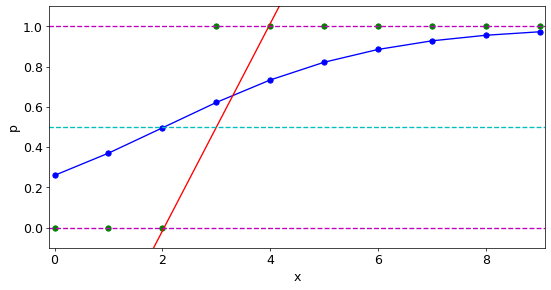

In [11]:
# Wizualizacja wygenerowanych danych
# Ustawienia związane z wyświetlaniem
matplotlib.rcParams.update({'font.size': 14})
f = plt.figure(figsize=(10, 5), dpi=64)
f1 = f.add_subplot(111)
f1.set_xlabel('x')
f1.set_ylabel('p')
f1.set_xlim([-0.1,9.1])
f1.set_ylim([-0.1,1.1])
# wartości prawdopodobieństwa przypisania do klasy 1:
prob = ((model.predict_proba(x).reshape(20,))[1::2])
f1.plot(x,prob, "bo-")
# wynik predykcji
f1.plot(x,model.predict(x), 'go')
# wykreślenie zależności z współczynników liniowych
y_lin = model.intercept_ + model.coef_*x
f1.plot(x,y_lin, 'r')
#wykreślenie linii pomocniczych
f1.plot(t,0*t+1, "m--")
f1.plot(t,0*t, "m--")
f1.plot(t,0*t+0.5, "c--")
plt.show()

W celu uzyskania większej ilości informacji na temat dokładności modelu, można skorzystać z macierzy pomyłek, co w tym przypadku sprowadza się do użycia funkcji <i>confusion_matrix()</i> działającej na aktualnych danych oraz tych uzyskanych z predykcji. 

In [12]:
confusion_matrix(y, model.predict(x))

array([[3, 1],
       [0, 6]], dtype=int64)

W rezultacie otrzymama się informacje o predykcjach prawdziwie negatywnych TN (3), fałszywie negatywnych FN (0), fałszywych pozytywnych FP (1) oraz o prawdziwych pozytywnych TP (6).

Pełniejszy raport z procesu klasyfikacji uzyskuje się za pomocą funkcji <i>classification_report()</i>, gdzie jako argumenty podaje się również aktualne dane oraz te uzyskane z predykcji.

In [13]:
print(classification_report(y, model.predict(x)))

              precision    recall  f1-score   support

           0       1.00      0.75      0.86         4
           1       0.86      1.00      0.92         6

    accuracy                           0.90        10
   macro avg       0.93      0.88      0.89        10
weighted avg       0.91      0.90      0.90        10



# Zadania do wykonania

<p><b>Zadanie 1</b></p>
Zbadaj zachowanie się treningu modelu w zależności od różnych wartości parametru C, który określa siłę regularyzacji.
<p><b>Zadanie 2</b></p>
Stwórz dane wejściowe o liczbie większej niż 100, które nie będą reprezentowały równych klas np. w stosunku 3:7. Jaki będzie wynik predykcji takiego modelu. 

In [1]:
# Rozwiązanie Zadania 1
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

x_train = np.arange(20).reshape(-1, 1)
y_train = np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

# Badanie różnych wartości C (odwrótność siły regularyzacji - mniejsze C to silniejsza regularyzacja)
C_values = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]

print("ZADANIE 1: Zmiana parametru C")
for c in C_values:
    model_c = LogisticRegression(solver='liblinear', C=c, random_state=0)
    model_c.fit(x_train, y_train)
    score = model_c.score(x_train, y_train)
    print(f"Dla C = {c:<7} | a0 = {model_c.intercept_[0]:<10.4f} | a1 = {model_c.coef_[0][0]:<10.4f} | Dokładność (Score) = {score:.2f}")

# Obserwacja: Wraz ze wzrostem parametru C model ma mniejszą karę za dopasowanie wag (słaba regularyzacja), 
# przez co współczynnik a1 (coef_) rośnie i model dopasowuje się bardziej stanowczo do danych treningowych.


ZADANIE 1: Zmiana parametru C
Dla C = 0.001   | a0 = -0.0007    | a1 = 0.0368     | Dokładność (Score) = 0.60
Dla C = 0.01    | a0 = -0.0286    | a1 = 0.0948     | Dokładność (Score) = 0.60
Dla C = 0.1     | a0 = -0.3200    | a1 = 0.1423     | Dokładność (Score) = 0.70
Dla C = 1.0     | a0 = -1.7991    | a1 = 0.2850     | Dokładność (Score) = 0.90
Dla C = 10.0    | a0 = -4.9855    | a1 = 0.6236     | Dokładność (Score) = 0.95
Dla C = 100.0   | a0 = -11.1902   | a1 = 1.3342     | Dokładność (Score) = 1.00



ZADANIE 2: Niezbalansowane klasy (3:7)
Macierz pomyłek:
[[ 45  15]
 [  4 136]]

Raport klasyfikacji:
              precision    recall  f1-score   support

         0.0       0.92      0.75      0.83        60
         1.0       0.90      0.97      0.93       140

    accuracy                           0.91       200
   macro avg       0.91      0.86      0.88       200
weighted avg       0.91      0.91      0.90       200



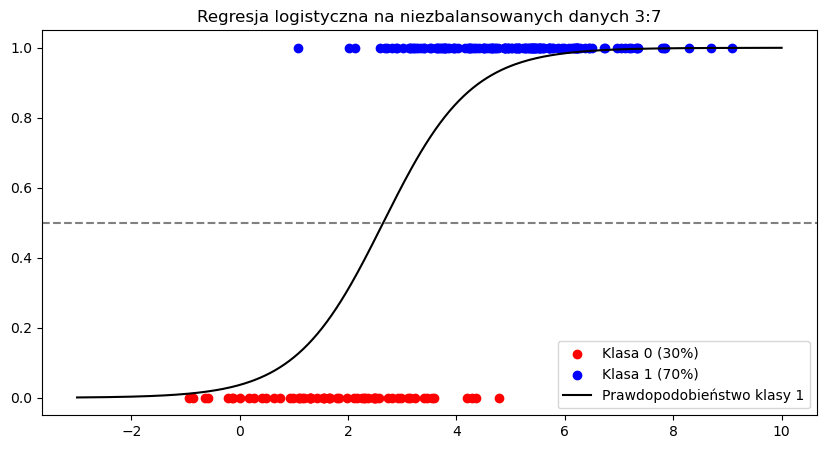

In [2]:
# Rozwiązanie Zadania 2
print("\nZADANIE 2: Niezbalansowane klasy (3:7)")

# Klasa 0: 60 próbek, Klasa 1: 140 próbek (razem 200, czyli stosunek 3:7 i >100)
# Wymieszane proste dane by zobaczyć problem:
np.random.seed(42)
X_class0 = np.random.normal(loc=2.0, scale=1.5, size=(60, 1))
y_class0 = np.zeros(60)

X_class1 = np.random.normal(loc=5.0, scale=1.5, size=(140, 1))
y_class1 = np.ones(140)

X_imbalanced = np.vstack((X_class0, X_class1))
y_imbalanced = np.concatenate((y_class0, y_class1))

# Trening modelu Regresji Logistycznej
model_imb = LogisticRegression(solver='liblinear')
model_imb.fit(X_imbalanced, y_imbalanced)

y_pred = model_imb.predict(X_imbalanced)

print("Macierz pomyłek:")
print(confusion_matrix(y_imbalanced, y_pred))

print("\nRaport klasyfikacji:")
print(classification_report(y_imbalanced, y_pred))

# Wizualizacja dopasowania bazy
X_test = np.linspace(-3, 10, 300).reshape(-1, 1)
y_prob = model_imb.predict_proba(X_test)[:, 1]

plt.figure(figsize=(10,5))
plt.scatter(X_class0, y_class0, color='red', label='Klasa 0 (30%)')
plt.scatter(X_class1, y_class1, color='blue', label='Klasa 1 (70%)')
plt.plot(X_test, y_prob, color='black', label='Prawdopodobieństwo klasy 1')
plt.axhline(0.5, color='gray', linestyle='--')
plt.title('Regresja logistyczna na niezbalansowanych danych 3:7')
plt.legend()
plt.show()

![stopka.svg](stopka.svg)

### Wnioski do ćwiczenia 4

**Zadanie 1 - badanie parametru C (regularyzacja):**
*   Parametr $C$ to odwrotność siły regularyzacji (im mniejsze $C$, tym silniejsza kara nakładana na wielkości współczynników).
*   **Dla małych wartości $C$ (np. 0.001 - 0.01):** Regularyzacja jest bardzo silna, przez co wagi ($a_0, a_1$) są małe i bliskie zera. Prowadzi to do niedouczenia (underfitting) – w naszym teście model osiąga niski *Score* rzędu 60%.
*   **Dla dużych wartości $C$ (np. 10.0 - 100.0):** Model pozwala swoim współczynnikom nienaturalnie urosnąć w celu idealnego dopasowania podane punkty treningowe (słaba regularyzacja). Widzimy gwałtowny wzrost wartości predyktora $a_1$ i *Score* rosnącę do imponujących 100%. Należy jednak pamiętać, że zbyt słaba regularyzacja przy bardziej skomplikowanych danych łatwo prowadzi do utraty właściwości generalizacyjnych i przeuczenia (overfitting).

**Zadanie 2 - badanie niezbalansowanych klas (np. 30% punktów dla klasy 0, 70% dla klasy 1):**
*   W naszym eksperymencie przeprowadziliśmy podział 60:140 dla wygenerowanych dwóch skupisk danych.
*   Wyniki z **Raportu klasyfikacji** wyraźnie pokazują różnicę metryki *Recall* (czułość) – dla popularnej (dużej) klasy wynosi blisko 97%, natomiast dla mniejszościowej tylko 75%.
*   **Wniosek:** Algorytm uczenia maszynowego "optymalizuje" całościowo błąd dla wszystkich przypadków razem wziętych, więc statystycznie opłaca mu się być bardziej pobłażliwym dla przewidywania dużej klasy 1, nawet za cenę częstszych pomyłek dla klasy 0. Macierz pomyłek to potwierdza – występuje $15$ błędów typu *False Positive* (model wskazał na klasę 1, gdy to była w rzeczywiśtości klasa 0), podczas gdy *False Negative* to tylko 4 błędy. Próg odcięcia decyzyjnego przesuwa się lekko w stronę mniejszej klasy. W takich rzczywistych projektach niezbędne byłoby użycie argumentu `class_weight='balanced'` w modelu.